In [1]:
import pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
# Define constants
#

DELTA_T = 0.25  # 15 min in Hours
N = 96  # Number of horizon time steps

BAT_CAP = 5.12*4                # kWh
BAT_P_MAX = 4.0*3               # kW
ETA_CH = np.sqrt(0.95) * 0.96   # 95% BESS round-trip efficiency * 96% inverter power factor
ETA_DIS = np.sqrt(0.95) * 0.96  # 95% BESS round-trip efficiency * 96% inverter power factor
SOC_MIN = 0.1 * BAT_CAP
SOC_MAX = 0.9 * BAT_CAP


In [3]:
import pulp
import numpy as np
import pandas as pd


def optimize_day(
    price_sell: pd.Series,   # ct/kWh
    price_buy: pd.Series,   # ct/kWh
    pv: pd.Series,            # kW
    load: pd.Series,          # kW
    soc0: float,              # kWh
) -> dict:

    # --- Konsistenzcheck ---
    assert price_sell.index.equals(pv.index)
    assert pv.index.equals(load.index)

    time_index = price_sell.index
    N = len(time_index)
    T = range(N)

    # Gewinnmaximierungsproblem
    model = pulp.LpProblem("DayAheadOpt", pulp.LpMaximize)

    # Variablen
    p_ch   = pulp.LpVariable.dicts("p_ch", T, 0, BAT_P_MAX)
    p_dis  = pulp.LpVariable.dicts("p_dis", T, 0, BAT_P_MAX)
    soc    = pulp.LpVariable.dicts("soc", T, SOC_MIN, SOC_MAX)

    p_sell = pulp.LpVariable.dicts("p_sell", T, 0)
    p_buy  = pulp.LpVariable.dicts("p_buy", T, 0)

    # Binärvariable gegen gleichzeitiges Laden/Entladen
    y = pulp.LpVariable.dicts("y", T, 0, 1, cat="Binary")

    # SOC-Dynamik
    for t in T:
        if t == 0:
            model += soc[t] == soc0 + DELTA_T * (
                ETA_CH * p_ch[t] - p_dis[t] / ETA_DIS
            )
        else:
            model += soc[t] == soc[t-1] + DELTA_T * (
                ETA_CH * p_ch[t] - p_dis[t] / ETA_DIS
            )

    # Lade-/Entlade-Exklusivität
    for t in T:
        model += p_ch[t]  <= BAT_P_MAX * y[t]
        model += p_dis[t] <= BAT_P_MAX * (1 - y[t])

    # Leistungsbilanz
    for t in T:
        model += (
            pv.iloc[t] + p_buy[t] + p_dis[t]
            ==
            load.iloc[t] + p_sell[t] + p_ch[t]
        )

    # Zielfunktion: Erlös – Kosten
    model += pulp.lpSum(
        (price_sell.iloc[t] * p_sell[t]
         - price_buy.iloc[t] * p_buy[t]) * DELTA_T
        for t in T
    )

    model.solve(pulp.PULP_CBC_CMD(msg=False))

    # --- Rückgabe als pandas.Series ---
    return {
        "soc":    pd.Series([soc[t].value() for t in T], index=time_index),
        "p_ch":   pd.Series([p_ch[t].value() for t in T], index=time_index),
        "p_dis":  pd.Series([p_dis[t].value() for t in T], index=time_index),
        "p_sell": pd.Series([p_sell[t].value() for t in T], index=time_index),
        "p_buy":  pd.Series([p_buy[t].value() for t in T], index=time_index),
    }


In [4]:
act_day = pd.date_range(
    start="2025-12-18 00:00",
    end="2025-12-18 23:45",
    freq="15min",
    tz="Europe/Berlin",
    )

df_energy = pd.read_csv(
    "../data/energy_data.csv",
    index_col=0,
    parse_dates=True,
    )
pv_forecast = df_energy["Production"].loc[act_day]
load_forecast = df_energy["Consumption"].loc[act_day]

# VKW dynmaische Preise in ct/kWh
df_prices_epex = pd.read_csv(
    "../data/day_ahead_prices.csv",
    index_col=0,
    parse_dates=True,
    )
prices_epex = df_prices_epex["day_ahead_price_EUR_MWh"].loc[act_day]
prices_epex = prices_epex * 100 / 1_000  # Umrechnung in ct/kWh
price_sell = prices_epex - 0.6
price_buy  = prices_epex + 1.44

result = optimize_day(
    price_sell=price_sell,
    price_buy=price_buy,
    pv=pv_forecast,
    load=load_forecast,
    soc0=0.5 * BAT_CAP,
)


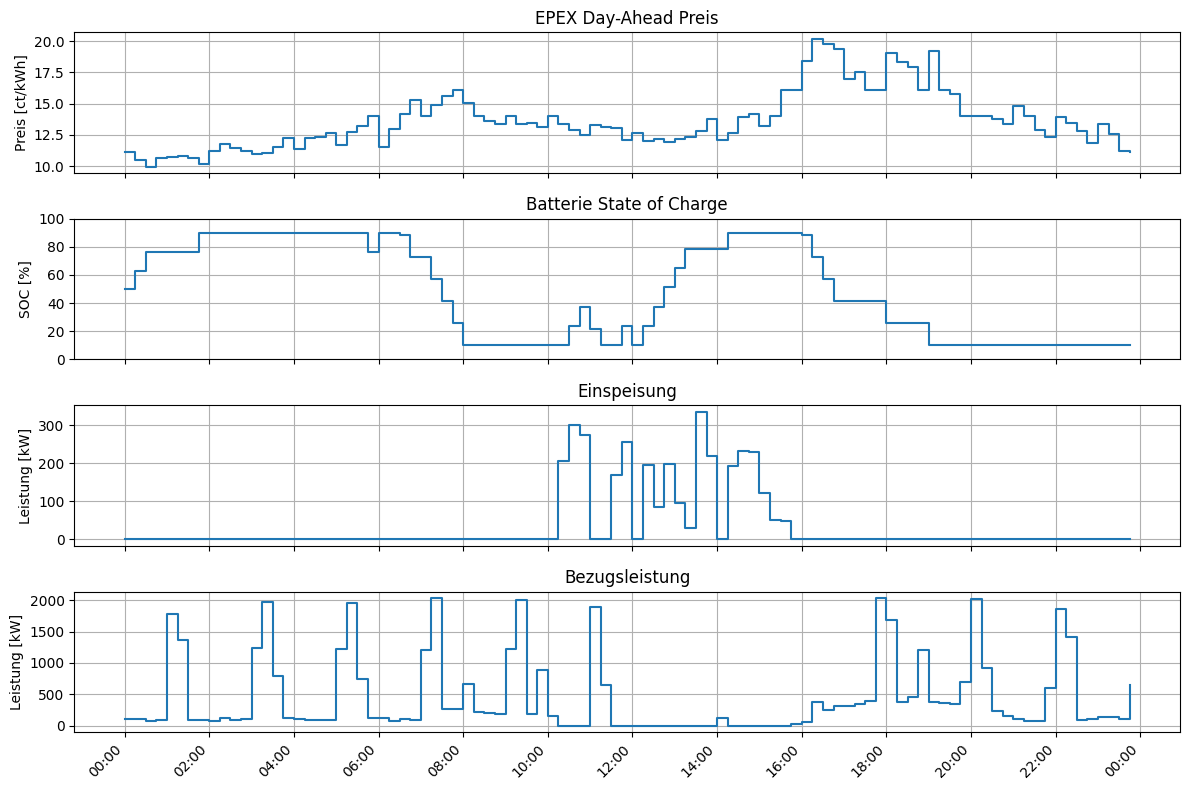

In [10]:
fig, (ax_price, ax_soc, ax_p_sell, ax_p_buy) = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
)

# --- Subplot 1: Day-Ahead Preis ---
ax_price.step(
    prices_epex.index,
    prices_epex.values,
    where="post",
)
ax_price.set_ylabel("Preis [ct/kWh]")
ax_price.set_title("EPEX Day-Ahead Preis")
ax_price.grid(True)

# --- Subplot 2: SOC in Prozent ---
soc_percent = 100 * result["soc"] / BAT_CAP

ax_soc.step(
    soc_percent.index,
    soc_percent.values,
    where="post",
)
ax_soc.set_ylabel("SOC [%]")
ax_soc.set_ylim(0, 100)
ax_soc.set_title("Batterie State of Charge")
ax_soc.grid(True)

# --- Subplot 3: Einspeisung & Bezug ---
ax_p_sell.step(
    result["p_sell"].index,
    result["p_sell"].values,
    where="post",
)

ax_p_sell.set_ylabel("Leistung [kW]")
ax_p_sell.set_title("Einspeisung")
ax_p_sell.grid(True)

# --- Subplot 4: Netzbezug ---
ax_p_buy.step(
    result["p_buy"].index,
    result["p_buy"].values,
    where="post",
)

ax_p_buy.set_ylabel("Leistung [kW]")
ax_p_buy.set_title("Bezugsleistung")
ax_p_buy.grid(True)

# --- X-Achse ---
locator = mdates.HourLocator(interval=2)      # alle 2 Stunden
formatter = mdates.DateFormatter("%H:%M", tz="Europe/Berlin")     # nur Uhrzeit
ax_p_buy.xaxis.set_major_locator(locator)
ax_p_buy.xaxis.set_major_formatter(formatter)
plt.setp(ax_p_buy.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()
